#ViT Baseline Model

Data from: https://github.com/ayeung009/APS360-Project/tree/main/data

### Setup

In [1]:
!git clone https://github.com/ayeung009/APS360-Project.git

!pip install torch torchvision transformers pandas pillow tqdm scikit-learn --quiet

Cloning into 'APS360-Project'...
remote: Enumerating objects: 1434, done.
remote: Counting objects: 100% (1434/1434), done.
remote: Compressing objects: 100% (1410/1410), done.
remote: Total 1434 (delta 70), reused 1307 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (1434/1434), 26.54 MiB | 20.28 MiB/s, done.
Resolving deltas: 100% (70/70), done.


In [2]:
import os
import re
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from transformers import ViTModel
from tqdm import tqdm

SEED = 360
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


### Paths (from Github)


In [15]:
PROJECT_ROOT = Path("/content/APS360-Project")
FINAL_LABELS_CSV = PROJECT_ROOT / "data" / "final_merged_dataset" / "final_labels.csv"

CHECKPOINT_DIR = Path("/content/checkpoints/baseline_vit")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Labels file:", FINAL_LABELS_CSV, "| exists:", FINAL_LABELS_CSV.exists())

Labels file: /content/APS360-Project/data/final_merged_dataset/final_labels.csv | exists: True


### Load data

Ensure the data is the correct one from GitHub.

In [23]:
labels_df = pd.read_csv(FINAL_LABELS_CSV)
labels_df["full_path"] = labels_df["image_path"].apply(lambda p: str(PROJECT_ROOT / p))

print(f"Total examples: {len(labels_df)}")
print(labels_df["source"].value_counts())
labels_df.head()

Total examples: 1061
source
self_generated    1000
roboflow            61
Name: count, dtype: int64


,image_path,expression,source,n_inputs,full_path
0,Logic-Gates-Detection-12/train/136_png.rf.d78e...,((A xor B) xor C),roboflow,3,/content/APS360-Project/Logic-Gates-Detection-...
1,Logic-Gates-Detection-12/train/Screenshot-2023...,((A and (not B)) or (B and (not A))),roboflow,2,/content/APS360-Project/Logic-Gates-Detection-...
2,Logic-Gates-Detection-12/train/35_png.rf.4ebb0...,((A or B) and (C or D) and (B or D)),roboflow,4,/content/APS360-Project/Logic-Gates-Detection-...
3,Logic-Gates-Detection-12/train/Screenshot-2023...,(A or B),roboflow,2,/content/APS360-Project/Logic-Gates-Detection-...
4,Logic-Gates-Detection-12/train/Screenshot-2023...,(A xnor B),roboflow,2,/content/APS360-Project/Logic-Gates-Detection-...


Fix paths to match github, not colab

In [31]:
OLD_ROBOFLOW_PREFIX = "Logic-Gates-Detection-12"
NEW_ROBOFLOW_PREFIX = "Logic Gates Detection.v12i.coco"

def resolve_path(p):
    if p.startswith("logic_dataset/"):
        # self-generated images live one level deeper in the repo
        return str(PROJECT_ROOT / "data" / "self_generated_data" / p)
    else:
        # Roboflow images: just the folder rename + data/ prefix
        p = p.replace(OLD_ROBOFLOW_PREFIX, NEW_ROBOFLOW_PREFIX)
        return str(PROJECT_ROOT / "data" / p)

labels_df["full_path"] = labels_df["image_path"].apply(resolve_path)

In [32]:
missing = [p for p in labels_df["full_path"] if not Path(p).exists()]
print(f"Missing files: {len(missing)} / {len(labels_df)}")
if missing:
    print("First few missing paths:", missing[:5])

Missing files: 0 / 1061


### Train / validation / testing split: 70,15,15

In [34]:
train_df, temp_df = train_test_split(
    labels_df, test_size=0.30, random_state=SEED,
    stratify=labels_df["source"],
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df["source"],
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 742 | Val: 159 | Test: 160


### Tokenizer


In [35]:
SPECIAL = ["<pad>", "<bos>","<eos>"]

TOKENS = [
    "A", "B", "C", "D", "E",
    "and", "or", "xor", "nand", "nor", "xnor", "not",
    "(", ")",
]

vocab = SPECIAL + TOKENS
stoi = {token: i for i, token in enumerate(vocab)}
itos = {i: t for t, i in stoi.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX = stoi["<pad>"]
BOS_IDX = stoi["<bos>"]
EOS_IDX = stoi["<eos>"]

print(f"Vocab size: {VOCAB_SIZE}")

def tokenize(expr):
    expr = expr.replace("(", " ( ").replace(")", " ) ")
    tokens = expr.split()
    ids = [BOS_IDX]
    for t in tokens:
        ids.append(stoi[t])
    ids.append(EOS_IDX)
    return ids

def detokenize(ids):
    tokens = [itos[i] for i in ids if i not in (PAD_IDX, BOS_IDX, EOS_IDX)]
    out = []
    for i, t in enumerate(tokens):
        if t == ")" and out and out[-1] == " ":
            out.pop()  # no spac before a closing paren
        out.append(t)
        if t != "(":
            out.append(" ")
    return "".join(out).strip()

# Quickcheck
_test_expr = "(D xnor A) nor B"
_ids = tokenize(_test_expr)
print(f"'{_test_expr}' -> {_ids} -> '{detokenize(_ids)}'")

Vocab size: 17
'(D xnor A) nor B' -> [1, 15, 6, 13, 3, 16, 12, 4, 2] -> '(D xnor A) nor B'


### Dataset

Reads in the dataset and edits the image to fit the model (3 channels)


In [36]:
IMAGE_SIZE = 224

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.Grayscale(num_output_channels=3),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomRotation(degrees=3),  #small onlysince circuits aren't rotation-invariant
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class LogicDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.full_path).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(tokenize(row.expression), dtype=torch.long)
        return img, label

### Collate & DataLoaders

In [37]:
def collate(batch):
    images, labels = zip(*batch)
    images = torch.stack(images)
    labels = pad_sequence(labels, batch_first=True, padding_value=PAD_IDX)
    return images, labels

BATCH_SIZE = 16

train_loader = DataLoader(
    LogicDataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate,
)
val_loader = DataLoader(
    LogicDataset(val_df, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate,
)
test_loader = DataLoader(
    LogicDataset(test_df, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate,
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 47 | Val: 10 | Test: 10


### Sanity check

Confirms images and decoded labels line up before spending time training.

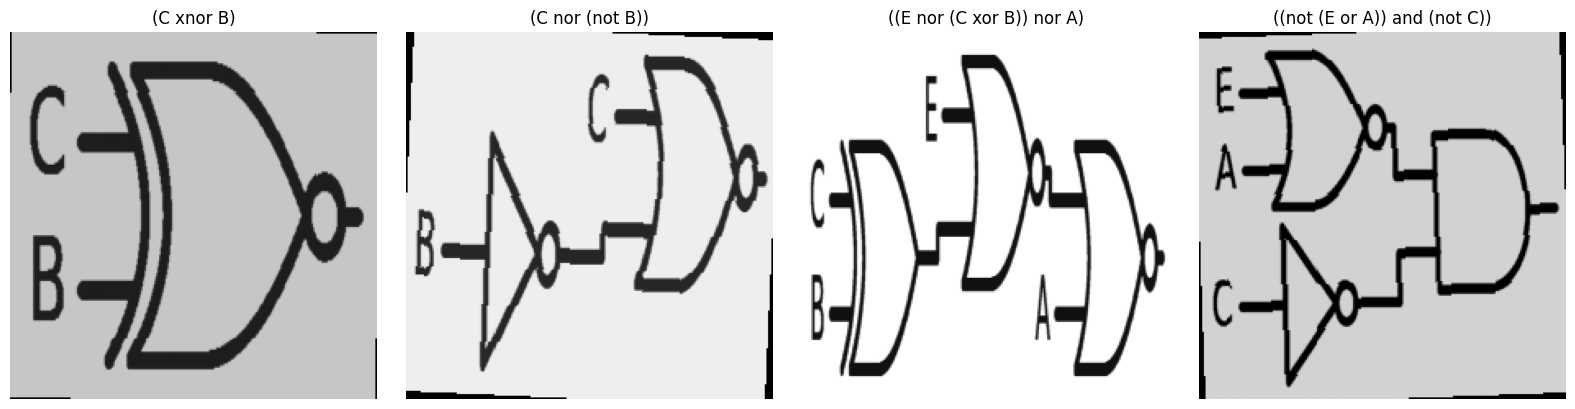

In [47]:
def sanity_check(loader, n=4):
    images, labels = next(iter(loader))
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for i in range(n):
        img = images[i] * std + mean
        axes[i].imshow(img.permute(1, 2, 0).clamp(0, 1))
        axes[i].set_title(detokenize(labels[i].tolist()))
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

sanity_check(train_loader)

### Positional encoding

The original draft fed token embeddings straight into the Transformer decoder
with no positional information at all

In [48]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        self.pos_embedding =nn.Embedding(max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        return x + self.pos_embedding(positions)

### ViT encoder (pretrained: google/vit-base-patch16-224)

In [49]:
encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")
D_MODEL = encoder.config.hidden_size
print(f"ViT hidden size: {D_MODEL}")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT hidden size: 768


### Decoder

Adding a causal mask (tgt_mask) is essential for preventing the model from "cheating" during training. Without it, the decoder can see future tokens, leading to artificially low loss that fails to translate to real-world performance.

In [50]:
class ExpressionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead=8, num_layers=4, max_len=64):
        super().__init__()
        self.embedding =nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, memory, tokens, tgt_key_padding_mask=None):
        seq_len = tokens.size(1)
        x = self.pos_encoding(self.embedding(tokens))

        causal_mask =nn.Transformer.generate_square_subsequent_mask(seq_len).to(tokens.device)
        causal_mask = causal_mask == float("-inf")  # bool form -- avoids a dtype
        # mismatch with the bool padding mask that silently degrades masking
        # in newer PyTorch versions if you mix a float mask with a bool one.

        out = self.decoder(
            x, memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )
        return self.fc(out)

### Full model

In [51]:
class ViTLogicModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, tokens, tgt_key_padding_mask=None):
        memory = self.encoder(pixel_values=images).last_hidden_state
        return self.decoder(memory, tokens, tgt_key_padding_mask=tgt_key_padding_mask)

model = ViTLogicModel(encoder, ExpressionDecoder(VOCAB_SIZE, D_MODEL)).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 117,976,081


### Metrics

Token-level accuracy tracks how many individual parts of an expression are correct, it is often misleadingly high because a model can get most of a long sequence right before failing at the final step.

Exact-match accuracy is the true measure of success; it only counts the expression as "correct" if the entire string perfectly matches the ground truth.

In [52]:
def compute_metrics(logits, targets):
    preds = logits.argmax(dim=-1)
    mask = targets != PAD_IDX

    correct_tokens = ((preds == targets) & mask).sum().item()
    total_tokens = mask.sum().item()
    token_acc = correct_tokens / max(total_tokens, 1)

    exact_matches = 0
    for p, t, m in zip(preds, targets, mask):
        p_valid = p[m]
        t_valid = t[m]
        if torch.equal(p_valid, t_valid):
            exact_matches += 1
    exact_acc = exact_matches / len(targets)

    return token_acc, exact_acc

### Training loop

In [53]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_token_acc, total_exact_acc, n_batches = 0.0, 0.0, 0.0, 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)
            inp = labels[:, :-1]
            target = labels[:, 1:]
            pad_mask = (inp == PAD_IDX)

            logits = model(images, inp, tgt_key_padding_mask=pad_mask)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            token_acc, exact_acc = compute_metrics(logits, target)
            total_loss += loss.item()
            total_token_acc += token_acc
            total_exact_acc += exact_acc
            n_batches += 1

    return (total_loss / n_batches, total_token_acc /n_batches, total_exact_acc / n_batches)

In [54]:
EPOCHS = 20
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_token_acc": [], "val_exact_acc": []}

for epoch in range(EPOCHS):
    train_loss, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_token_acc, val_exact_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_token_acc"].append(val_token_acc)
    history["val_exact_acc"].append(val_exact_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_token_acc={val_token_acc:.3f} | "
          f"val_exact_acc={val_exact_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pth")
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")

pd.DataFrame(history).to_csv(CHECKPOINT_DIR /"training_history.csv", index=False)

Epoch 1/20 | train_loss=1.4642 | val_loss=1.3034 | val_token_acc=0.559 | val_exact_acc=0.006
  -> New best model saved (val_loss=1.3034)


Epoch 2/20 | train_loss=1.0739 | val_loss=1.0426 | val_token_acc=0.631 | val_exact_acc=0.006
  -> New best model saved (val_loss=1.0426)


Epoch 3/20 | train_loss=0.9041 | val_loss=0.9196 | val_token_acc=0.669 | val_exact_acc=0.025
  -> New best model saved (val_loss=0.9196)


Epoch 4/20 | train_loss=0.8143 | val_loss=0.8127 | val_token_acc=0.687 | val_exact_acc=0.056
  -> New best model saved (val_loss=0.8127)


Epoch 5/20 | train_loss=0.6667 | val_loss=0.6277 | val_token_acc=0.757 | val_exact_acc=0.069
  -> New best model saved (val_loss=0.6277)


...

Epoch 16/20 | train_loss=0.1037 | val_loss=0.2721 | val_token_acc=0.903 | val_exact_acc=0.276
  -> New best model saved (val_loss=0.2721)


Epoch 17/20 | train_loss=0.1044 | val_loss=0.2615 | val_token_acc=0.908 | val_exact_acc=0.289
  -> New best model saved (val_loss=0.2615)


Epoch 18/20 | train_loss=0.0876 | val_loss=0.2381 | val_token_acc=0.918 | val_exact_acc=0.340
  -> New best model saved (val_loss=0.2381)


Epoch 19/20 | train_loss=0.0781 | val_loss=0.2799 | val_token_acc=0.910 | val_exact_acc=0.288


Epoch 20/20 | train_loss=0.0839 | val_loss=0.3135 | val_token_acc=0.893 | val_exact_acc=0.238


### Training curves

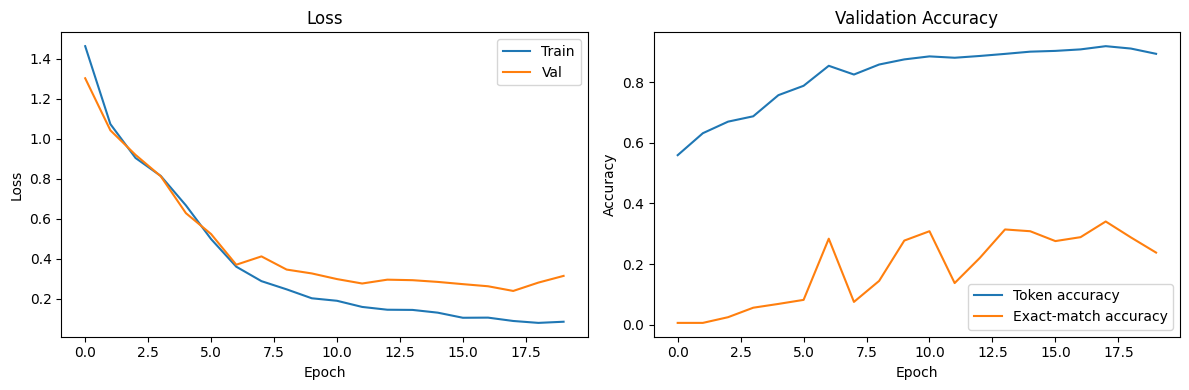

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label= "Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")
axes[1].plot(history["val_token_acc"], label="Token accuracy")
axes[1].plot(history["val_exact_acc"], label="Exact-match accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].set_title("Validation Accuracy")
plt.tight_layout()
plt.show()

### Test set evaluation

Load the best checkpoint (by val loss) and evaluate once on the held-out test set.

In [58]:
model.load_state_dict(torch.load(CHECKPOINT_DIR/ "best_model.pth"))
test_loss, test_token_acc, test_exact_acc = run_epoch(test_loader, train=False)
print(f"Test loss: {test_loss:.4f} | Test token acc: {test_token_acc:.3f} | Test exact-match acc: {test_exact_acc:.3f}")

Test loss: 0.3622 | Test token acc: 0.895 | Test exact-match acc: 0.319


In [62]:
import itertools

#Boolean equivalence checker
# Tests whether two expressions compute the same function over all variables
# for instance, not not A is the same as A, but the raw strings do not match.
# This should still be equivalent logically.

BINOPS = {"and", "or", "xor", "nand", "nor", "xnor"}

def tokenize_str(expr):
    expr = expr.replace("(", " ( ").replace(")", " ) ")
    return expr.split()

class _Parser:
    def __init__(self, tokens):
        self.tokens = tokens
        self.pos = 0
    def peek(self):
        return self.tokens[self.pos] if self.pos < len(self.tokens) else None
    def consume(self):
        t = self.tokens[self.pos]; self.pos += 1; return t
    def parse_primary(self):
        t = self.peek()
        if t == "not":
            self.consume(); return ("not", self.parse_primary())
        elif t == "(":
            self.consume(); node = self.parse_expr(); assert self.consume() == ")"; return node
        else:
            return ("var", self.consume())
    def parse_expr(self):
        node = self.parse_primary()
        while self.peek() in BINOPS:
            op = self.consume(); rhs = self.parse_primary()
            node = ("binop", op, node, rhs)
        return node

def parse_expr(expr):
    return _Parser(tokenize_str(expr)).parse_expr()

def evaluate(node, assignment):
    kind = node[0]
    if kind == "var": return assignment[node[1]]
    elif kind == "not": return not evaluate(node[1], assignment)
    else:
        _, op, l, r = node
        lv, rv = evaluate(l, assignment), evaluate(r, assignment)
        if op == "and": return lv and rv
        if op == "or": return lv or rv
        if op == "xor": return lv != rv
        if op == "nand": return not (lv and rv)
        if op == "nor": return not (lv or rv)
        if op == "xnor": return lv == rv

def get_variables(node):
    if node[0] == "var": return {node[1]}
    elif node[0] == "not": return get_variables(node[1])
    else: return get_variables(node[2]) | get_variables(node[3])

def are_equivalent(expr1, expr2):
    try:
        t1, t2 = parse_expr(expr1), parse_expr(expr2)
    except Exception:
        return False  # unparseable prediction -> not equivalent
    variables = sorted(get_variables(t1) | get_variables(t2))
    if not variables:
        return expr1 == expr2
    for bits in itertools.product([False, True], repeat=len(variables)):
        assignment = dict(zip(variables, bits))
        if evaluate(t1, assignment) != evaluate(t2, assignment):
            return False
    return True

# ---- Run over the full test set ----
model.load_state_dict(torch.load(CHECKPOINT_DIR / "best_model.pth"))
model.eval()

results = []
for idx in tqdm(range(len(test_df))):
    img_tensor, label_ids = LogicDataset(test_df, eval_transform)[idx]
    pred_expr = generate(model, img_tensor)
    true_expr = detokenize(label_ids.tolist())
    exact_match = (pred_expr == true_expr)
    equivalent = are_equivalent(pred_expr, true_expr) if not exact_match else True
    results.append({
        "true_expr": true_expr, "pred_expr": pred_expr,
        "exact_match": exact_match, "logically_equivalent": equivalent,
    })

results_df = pd.DataFrame(results)

n = len(results_df)
n_exact = results_df["exact_match"].sum()
n_equiv_not_exact = ((results_df["logically_equivalent"]) & (~results_df["exact_match"])).sum()
n_wrong = (~results_df["logically_equivalent"]).sum()

print(f"Exact string match:              {n_exact}/{n} ({n_exact/n:.1%})")
print(f"Equivalent but different phrasing: {n_equiv_not_exact}/{n} ({n_equiv_not_exact/n:.1%})")
print(f"Genuinely wrong:                 {n_wrong}/{n} ({n_wrong/n:.1%})")
print()
print(f"Total 'functionally correct' (exact + equivalent): {(n_exact+n_equiv_not_exact)/n:.1%}")

print("\nExamples of equivalent-but-different-phrasing cases:")
print(results_df[results_df["logically_equivalent"] & ~results_df["exact_match"]][["true_expr","pred_expr"]].head(10))

print("\nExamples of genuinely wrong predictions:")
print(results_df[~results_df["logically_equivalent"]][["true_expr","pred_expr"]].head(10))

100%|██████████| 160/160 [00:16<00:00,  9.72it/s]

Exact string match:              51/160 (31.9%)
Equivalent but different phrasing: 65/160 (40.6%)
Genuinely wrong:                 44/160 (27.5%)

Total 'functionally correct' (exact + equivalent): 72.5%

Examples of equivalent-but-different-phrasing cases:
                                      true_expr  \
0   (C or (not ((not E) and ((not D) xnor A))))   
4          (not (D xor ((E nor B) or (not C))))   
5              ((not (B nor (C nand E))) xor D)   
7            ((not (B and (not E))) or (not D))   
9                      ((not (D nand C)) xor A)   
11  ((not ((not C) or (E nand D))) nor (not A))   
19                (not ((C nor D) or (A or E)))   
20                ((not (D xor (not E))) and A)   
22                         (not ((not E) or B))   
23                      (not ((D nor A) nor B))   

                                 pred_expr  
0   (C or ((not E) nand ((not D) xnor A)))  
4          (D xnor ((E nor B) or (not C)))  
5           ((B or (not (C and E))) xor D)  


###Qualitative check

Generates an expression from scratch to see what the model
actually produces at inference time, which is the real test of whether the
causal masking fix worked as intended.

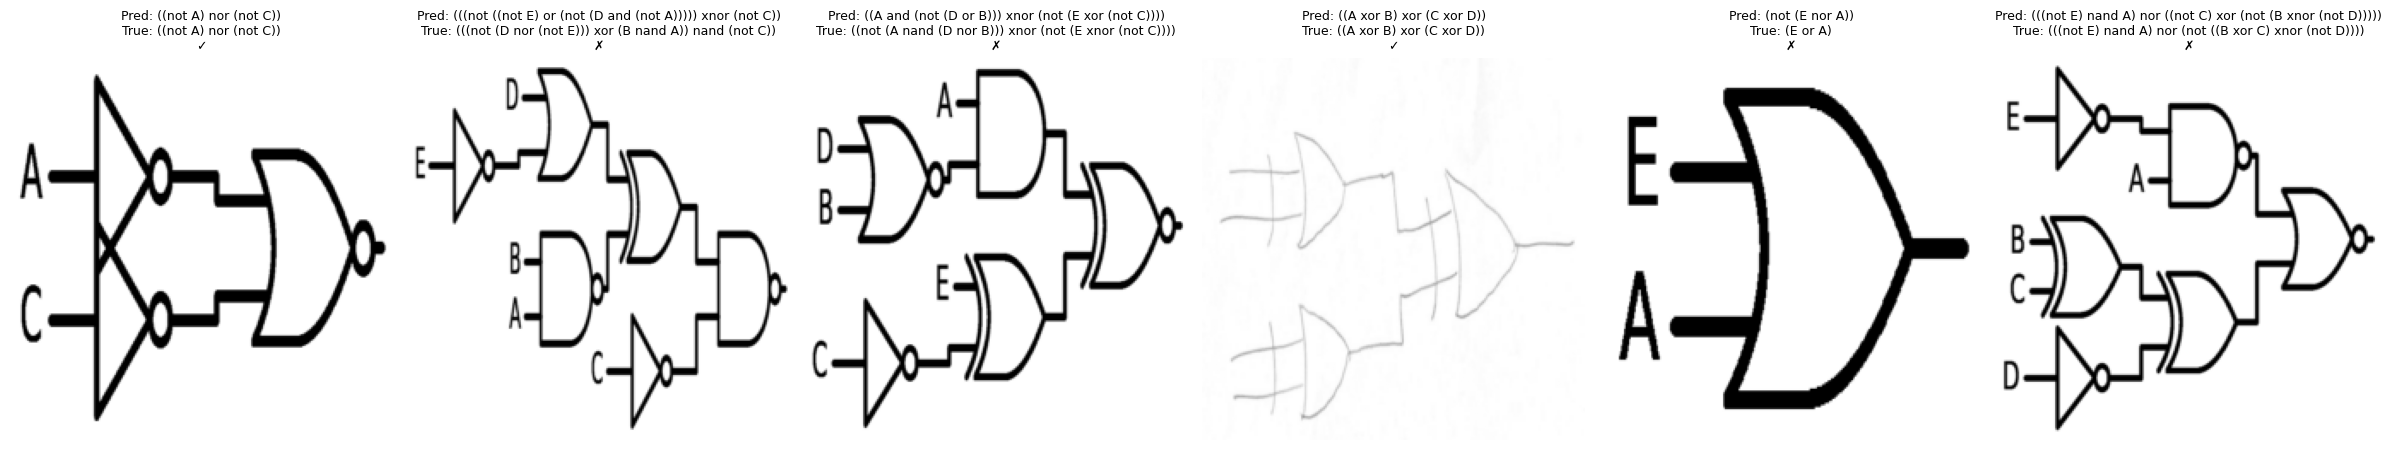

In [60]:
@torch.no_grad()
def generate(model, image_tensor, max_len=40):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    memory = model.encoder(pixel_values=image_tensor).last_hidden_state

    generated = [BOS_IDX]
    for _ in range(max_len):
        tokens = torch.tensor([generated], device=device)
        logits = model.decoder(memory, tokens)
        next_id = logits[0, -1].argmax().item()
        generated.append(next_id)
        if next_id == EOS_IDX:
            break
    return detokenize(generated)

# Show a handful of validation examples: predicted vs. ground truth
n_show = 6
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4.5))
mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

for i in range(n_show):
    img_tensor, label_ids = LogicDataset(val_df, eval_transform)[i]
    pred_expr = generate(model, img_tensor)
    true_expr = detokenize(label_ids.tolist())

    img_disp = img_tensor * std + mean
    axes[i].imshow(img_disp.permute(1, 2, 0).clamp(0, 1))
    match = "✓" if pred_expr == true_expr else "✗"
    axes[i].set_title(f"Pred: {pred_expr}\nTrue: {true_expr}\n{match}", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()